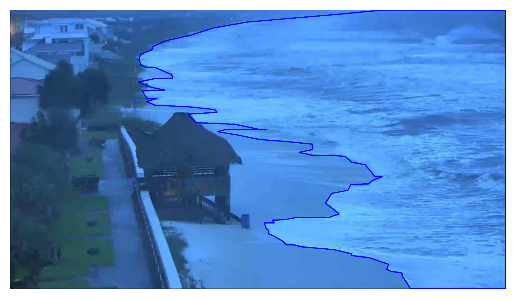

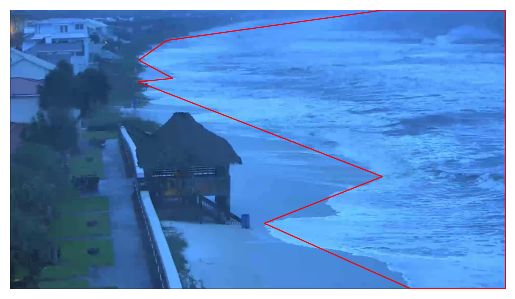

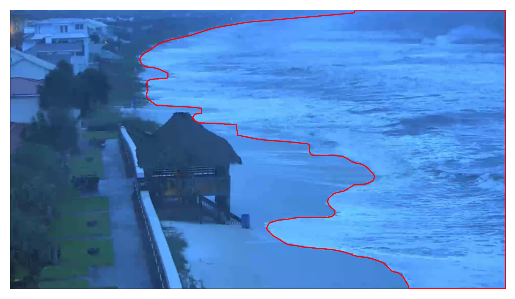

In [1]:
from glob import glob
import os, torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import label, skeletonize

from fil_finder import FilFinder2D
import astropy.units as u



selector = '/data/data2/motoko_WSSS_data/Water/poly-/mexico_beach_clip0/mexico_beach_10-10-2018-06-39-07_0.png'
selected_perf_msk_path = f'../Water/Annotations/{"/".join(selector.split("/")[-2:])}'
selected_img_path = f'../Water/JPEGImages/{"/".join(selector.split("/")[-2:])[:-3]}png'
img = np.pad(np.array(Image.open(selected_img_path).convert('RGB')),((1,1),(1,1),(0,0)))

msk_perf = np.pad(np.array(Image.open(selected_perf_msk_path).convert('L')),1).clip(max=1)

msk_poly = np.pad(np.array(Image.open(selected_perf_msk_path.replace('/Annotations/','/poly-/')).convert('L')),1).clip(max=1)

msk_rough = np.pad(np.array(Image.open(selected_perf_msk_path.replace('/Annotations/','/rough/')).convert('L')),1).clip(max=1)

a,c = 0,0
b,d = img.shape[:2]
plt.imshow(img[a:b,c:d])
plt.contour(msk_perf[a:b,c:d],colors='blue',linewidths=.25)
plt.axis('off')
plt.show()

plt.imshow(img[a:b,c:d])
plt.contour(msk_poly[a:b,c:d],colors='red',linewidths=.25)
plt.axis('off')
plt.show()

plt.imshow(img[a:b,c:d])
plt.contour(msk_rough[a:b,c:d],colors='red',linewidths=.25)
plt.axis('off')
plt.show()




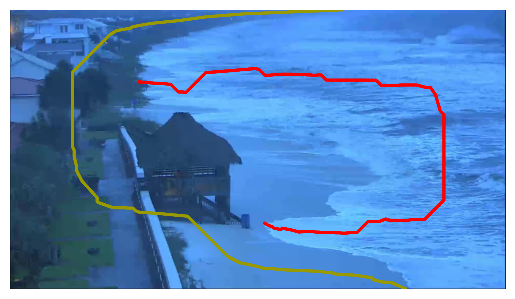

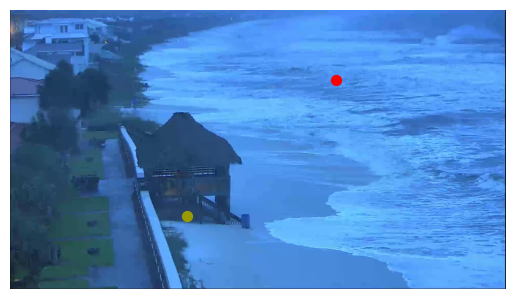

In [5]:
from skimage.morphology import dilation, erosion,disk
from sklearn.cluster import KMeans
pos_point_coords = []
neg_point_coords = []

plt.imshow(img[a:b,c:d])
scrib_msk = np.zeros_like(msk_perf[a:b,c:d])
skeleton = skeletonize(msk_perf[a:b,c:d]).astype('uint8')
fil = FilFinder2D(skeleton, distance= u.pc, mask=skeleton)
fil.preprocess_image(flatten_percent=50)
fil.create_mask(border_masking=True, verbose=False, use_existing_mask=True)
fil.medskel(verbose=False)
fil.analyze_skeletons(branch_thresh=100* u.pix, skel_thresh=10 * u.pix, prune_criteria='length')
# plt.imshow(fil.skeleton, cmap='gray')
plt.contour(fil.skeleton_longpath, colors='r')
plt.axis('off')

labelled_skeleton, max_id = label(fil.skeleton_longpath, return_num=True)
for component_id in range(1,max_id+1):
    scrib_coords = np.argwhere(labelled_skeleton==component_id)
    centroid = np.mean(scrib_coords, axis=0)
    arg_min_squared_distance = np.argmin(np.sum((scrib_coords - centroid)**2,axis=1))
    pos_point_coords.append(scrib_coords[arg_min_squared_distance])
    

skeleton = skeletonize(erosion(msk_perf[a:b,c:d] == 0,footprint=disk(15)) ).astype('uint8')
# temp = np.argwhere(skeleton>0)
# np.random.shuffle(temp)
# for i in range(2):
#     _coord = temp[i]
#     skeleton[_coord[0]:_coord[0]+1, _coord[1]:_coord[1]+1]=0

fil = FilFinder2D(skeleton, distance= u.pc, mask=skeleton)
fil.preprocess_image(flatten_percent=50)
fil.create_mask(border_masking=True, verbose=False, use_existing_mask=True)
fil.medskel(verbose=False)
fil.analyze_skeletons(branch_thresh=10* u.pix, skel_thresh=40 * u.pix, prune_criteria='length')
# plt.imshow(fil.skeleton, cmap='gray')
plt.contour(fil.skeleton_longpath, colors='#999900')
plt.axis('off')
plt.show()
scrib_coords = np.argwhere(fil.skeleton_longpath>0)
centroid = np.mean(scrib_coords, axis=0)
arg_min_squared_distance = np.argmin(np.sum((scrib_coords - centroid)**2,axis=1))
neg_point_coords.append(scrib_coords[arg_min_squared_distance])

pos_point_coords = np.array(pos_point_coords)
neg_point_coords = np.array(neg_point_coords)
plt.imshow(img[a:b,c:d])
plt.scatter(pos_point_coords[:,1],pos_point_coords[:,0],c='r',s=50)
plt.scatter(neg_point_coords[:,1],neg_point_coords[:,0],c='#999900',s=50)
plt.axis('off')
plt.show()


In [ ]:
import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img[a:b,c:d])
for component_id in range(1,max_id+1):
    pos_coords = np.argwhere(labelled == component_id)
    y0,x0 = pos_coords.min(axis=0)
    y1,x1 = pos_coords.max(axis=0)
    h,w = x1-x0+1, y1-y0+1
    deviation = (np.random.rand(4)*2-1)*.1*np.array([h,w,h,w])
    y0,x0,y1,x1 = (np.array([y0,x0,y1,x1])+deviation.clip(min=-20,max=20))
    rect = patches.Rectangle((x0-1, y0-1), x1.clip(max=d)-x0, y1.clip(max=b)-y0, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
ax.axis('off')
plt.show()
    

    
    